# Evaluate

This notebook evaluates the quality of the online alignments in a given experiment directory.

In [1]:
%matplotlib inline

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os
import os.path
from pathlib import Path
import pandas as pd
import pickle
import re
import import_ipynb
import system_utils
import eval_tools

## Calculate Alignment Errors

First we calculate the alignment errors of a given system on all evaluated measures.

**Note:** You can filter evaluation by specific composers or pieces by using the `piece_filter` parameter. For example:
- `piece_filter='bach'` to evaluate only Bach pieces
- `piece_filter='beeth'` to evaluate only Beethoven pieces  
- `piece_filter='mozart'` to evaluate only Mozart pieces
- `piece_filter='rach'` to evaluate only Rachmaninov pieces
- Leave `piece_filter=None` (default) to evaluate all pieces

In [3]:
from pyexpat import features


systems = ['NaivePairwiseDTW','NOA', 'OLTW', 'NOA-Mono']
modes = ['constant', 'random', 'continuous']
lags = [0, 100, 200, 300, 400, 500]
tsm = False # change
use_match_features = False

In [4]:
for mode_idx in range(len(modes)):
    for system_idx in range(len(systems)):
        exp_dir = 'experiments'
        if use_match_features:
            exp_dir += '_match'
        exp_dir = exp_dir + f'/{modes[mode_idx]}/{systems[system_idx]}'
        scenarios_dir = f'scenarios/{modes[mode_idx]}'
        # Build eval directory name: eval_tsm_match, eval_match, eval_tsm, or eval
        eval_prefix = 'eval'
        if tsm:
            eval_prefix += '_tsm'
        if use_match_features:
            eval_prefix += '_match'
        # Extract relative path from exp_dir (everything after the first '/')
        # This works for both 'experiments/' and 'experiments_match/'
        relative_path = '/' + '/'.join(exp_dir.split('/')[1:])
        eval_dir = eval_prefix + relative_path
        print(f"Evaluating {exp_dir}, saving to {eval_dir}")
        for lag_idx in range(len(lags)):
            lag = lags[lag_idx]
            eval_dir_with_lag = eval_dir + f'/lag{lag}'
            eval_tools.calcAlignErrors_batch(exp_dir, scenarios_dir, eval_dir_with_lag, '', tsm = tsm, lag = lag)

Evaluating experiments/constant/NaivePairwiseDTW, saving to eval/constant/NaivePairwiseDTW
Evaluating all scenarios
Evaluating scenario ID: s1
Evaluating scenario ID: s2
Evaluating scenario ID: s3
Evaluating scenario ID: s4
Evaluating scenario ID: s5
Evaluating scenario ID: s6
Evaluating scenario ID: s7
Evaluating scenario ID: s8
Evaluating scenario ID: s9
Evaluating scenario ID: s10
Evaluating scenario ID: s11
Evaluating scenario ID: s12
Evaluating scenario ID: s13
Evaluating scenario ID: s14
Evaluating scenario ID: s15
Evaluating scenario ID: s16
Evaluating scenario ID: s17
Evaluating scenario ID: s18
Evaluating scenario ID: s19
Evaluating scenario ID: s20
Evaluating scenario ID: s21
Evaluating scenario ID: s22
Evaluating scenario ID: s23
Evaluating scenario ID: s24
Evaluating scenario ID: s25
Evaluating scenario ID: s26
Evaluating scenario ID: s27
Evaluating scenario ID: s28
Evaluating scenario ID: s29
Evaluating scenario ID: s30
Evaluating scenario ID: s31
Evaluating scenario ID: s

## Plot Error vs Tolerance

We can visualize the results by plotting the error rate across a range of error tolerances.

In [5]:
def plotErrorVsTolerance(eval_dirs, maxTol, savefile = None, style='bar', tols=None, bar_tols=[100, 200, 500, 1000, 2000], piece_filter=None, mode=None):
    '''
    Plots the error rate across a range of error tolerances.
    
    Inputs
    eval_dir: the eval directories to plot
    maxTol: maximum error tolerance to consider (in milliseconds)
    savefile: if specified, will save the figure to the given filepath
    style: 'bar' or 'line'
    tols: list of error tolerances to evaluate at
    bar_tols: list of error tolerances to plot if using 'bar'
    '''
    
    errRates_list = []
    #color=['blue','orange','green','lightgreen','red'] # hard coded for main results figure
    for i, eval_dir in enumerate(eval_dirs):
    
        # load
        with open(f'{eval_dir}/lag0/errs.pkl', 'rb') as f:
            d = pickle.load(f)

        # flattened list
        errs = []
        for scenario_id in d:
            errs = np.append(errs, d[scenario_id][0])

        # calculate error rates
        if tols is None:
            tols = np.arange(maxTol+1)
        if bar_tols is None:
            bar_tols = tols
        errRates = np.zeros(len(tols))
        for j in range(len(tols)):
            errRates[j] = np.mean(np.abs(errs) > tols[j]/1000)
        errRates_list.append(errRates)
        
        if style == 'line':
            plt.plot(tols, errRates * 100.0)
        elif style == 'bar':
            bar_width = 0.1
            errs = [errRates[tol] * 100.0 for tol in range(len(bar_tols))]
            pos = np.arange(len(errs)) + i * bar_width
            # hard code for main results figure
            #plt.bar(pos, errs, width=bar_width, label=os.path.basename(eval_dir), color = color[i])
            plt.bar(pos, errs, width=bar_width, label=os.path.basename(eval_dir))
            plt.xticks([r + bar_width*len(eval_dirs)/2 for r in range(len(bar_tols))], map(str, bar_tols))
        
    plt.ylabel('Error Rate (%)')
    plt.xlabel('Error Tolerance (ms)')
    plt.legend([os.path.basename(eval_dir) for eval_dir in eval_dirs])
    plt.grid(linestyle='--')
    plt.title(f'Mode: {mode}')
    plt.ylim(0, 100)
    if piece_filter is not None:
        plt.title(f'Error Rate vs Error Tolerance for {piece_filter}')
    else:
        pass
    plt.show()
    if savefile:
        plt.savefig(savefile)

    return errRates_list, tols

Mode: constant
['eval/constant/NaivePairwiseDTW', 'eval/constant/NOA', 'eval/constant/OLTW', 'eval/constant/NOA-Mono']


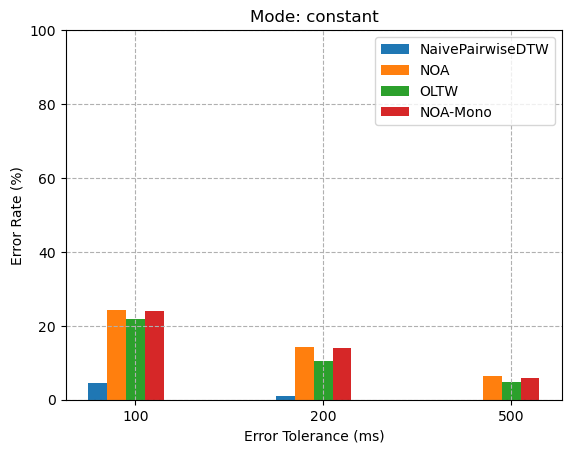

In [6]:
systems_to_compare = systems
tsm = False
tols = [100,200,500]
bar_tols = [100,200,500]
mode_type = modes[0]
eval_dirs = [f'eval{"_tsm" if tsm else ""}{"_match" if use_match_features else ""}/{mode_type}/{s}' for s in systems_to_compare]
print(f"Mode: {mode_type}")
print(eval_dirs)
errRates_list, tols = plotErrorVsTolerance(eval_dirs, maxTol = 1000,tols = tols, bar_tols = bar_tols, mode=mode_type)

In [11]:
# maxTol = 5000 # in milliseconds
# tsm = True
# tols = [100,200,500]
# eval_dir = f'eval{"_tsm" if tsm else ""}/{modes[0]}/{systems[1]}/lag100'
# print(eval_dir)
# print(errRates_list)
# errRates_list, tols = plotErrorVsTolerance([eval_dir], maxTol, tols = tols, savefile=False)
# for i in range(len(tols)):
#     print(errRates_list[0][i]*100.0)

Overlay multiple error curves for comparison:

In [12]:
# systems_to_compare = systems
# tsm = True
# eval_dirs = [f'eval{"_tsm" if tsm else ""}/{modes[1]}/{s}/lag0' for s in systems_to_compare]
# print(eval_dirs)
# errRates_list, tols = plotErrorVsTolerance(eval_dirs, maxTol = 1000,tols = tols)

In [12]:
errRates_list

[array([1., 1., 1.]),
 array([0.97399527, 0.97163121, 0.95862884]),
 array([0.6572104 , 0.3356974 , 0.13356974])]

### Plot Lags

In [13]:
tsm = True

from collections import defaultdict
def aggErrorRates(eval_root, tols = None):
    '''
    Plots the error rate across a range of error tolerances.
    
    Inputs
    eval_root: the root directory of the eval directories to aggregate
    tols: list of error tolerances to evaluate at
    '''
    
    errRates_dict = defaultdict(lambda: defaultdict(lambda: defaultdict(dict)))
    # Build eval directory name: eval_tsm_match, eval_match, eval_tsm, or eval
    eval_prefix = 'eval'
    if tsm:
        eval_prefix += '_tsm'
    if use_match_features:
        eval_prefix += '_match'
    for mode_idx in range(len(modes)):
        for system_idx in range(len(systems)):
            for lag_idx in range(len(lags)):
                lag = lags[lag_idx]
                eval_dir = f'{eval_prefix}/{modes[mode_idx]}/{systems[system_idx]}/lag{lag}'
                # print(eval_dir_with_lag)
    
                # load
                with open(f'{eval_dir}/errs.pkl', 'rb') as f:
                    d = pickle.load(f)

                # flattened list
                errs = []
                for scenario_id in d:
                    errs = np.append(errs, d[scenario_id][0])

                # calculate error rates
                errRates = {}
                for j in range(len(tols)):
                    errRates[tols[j]] = np.mean(np.abs(errs) > tols[j]/1000)
                errRates_dict[modes[mode_idx]][systems[system_idx]][lag] = errRates
        
    return errRates_dict

In [14]:
errors_dict = dict(aggErrorRates(eval_dirs, tols = [100,200,500]))

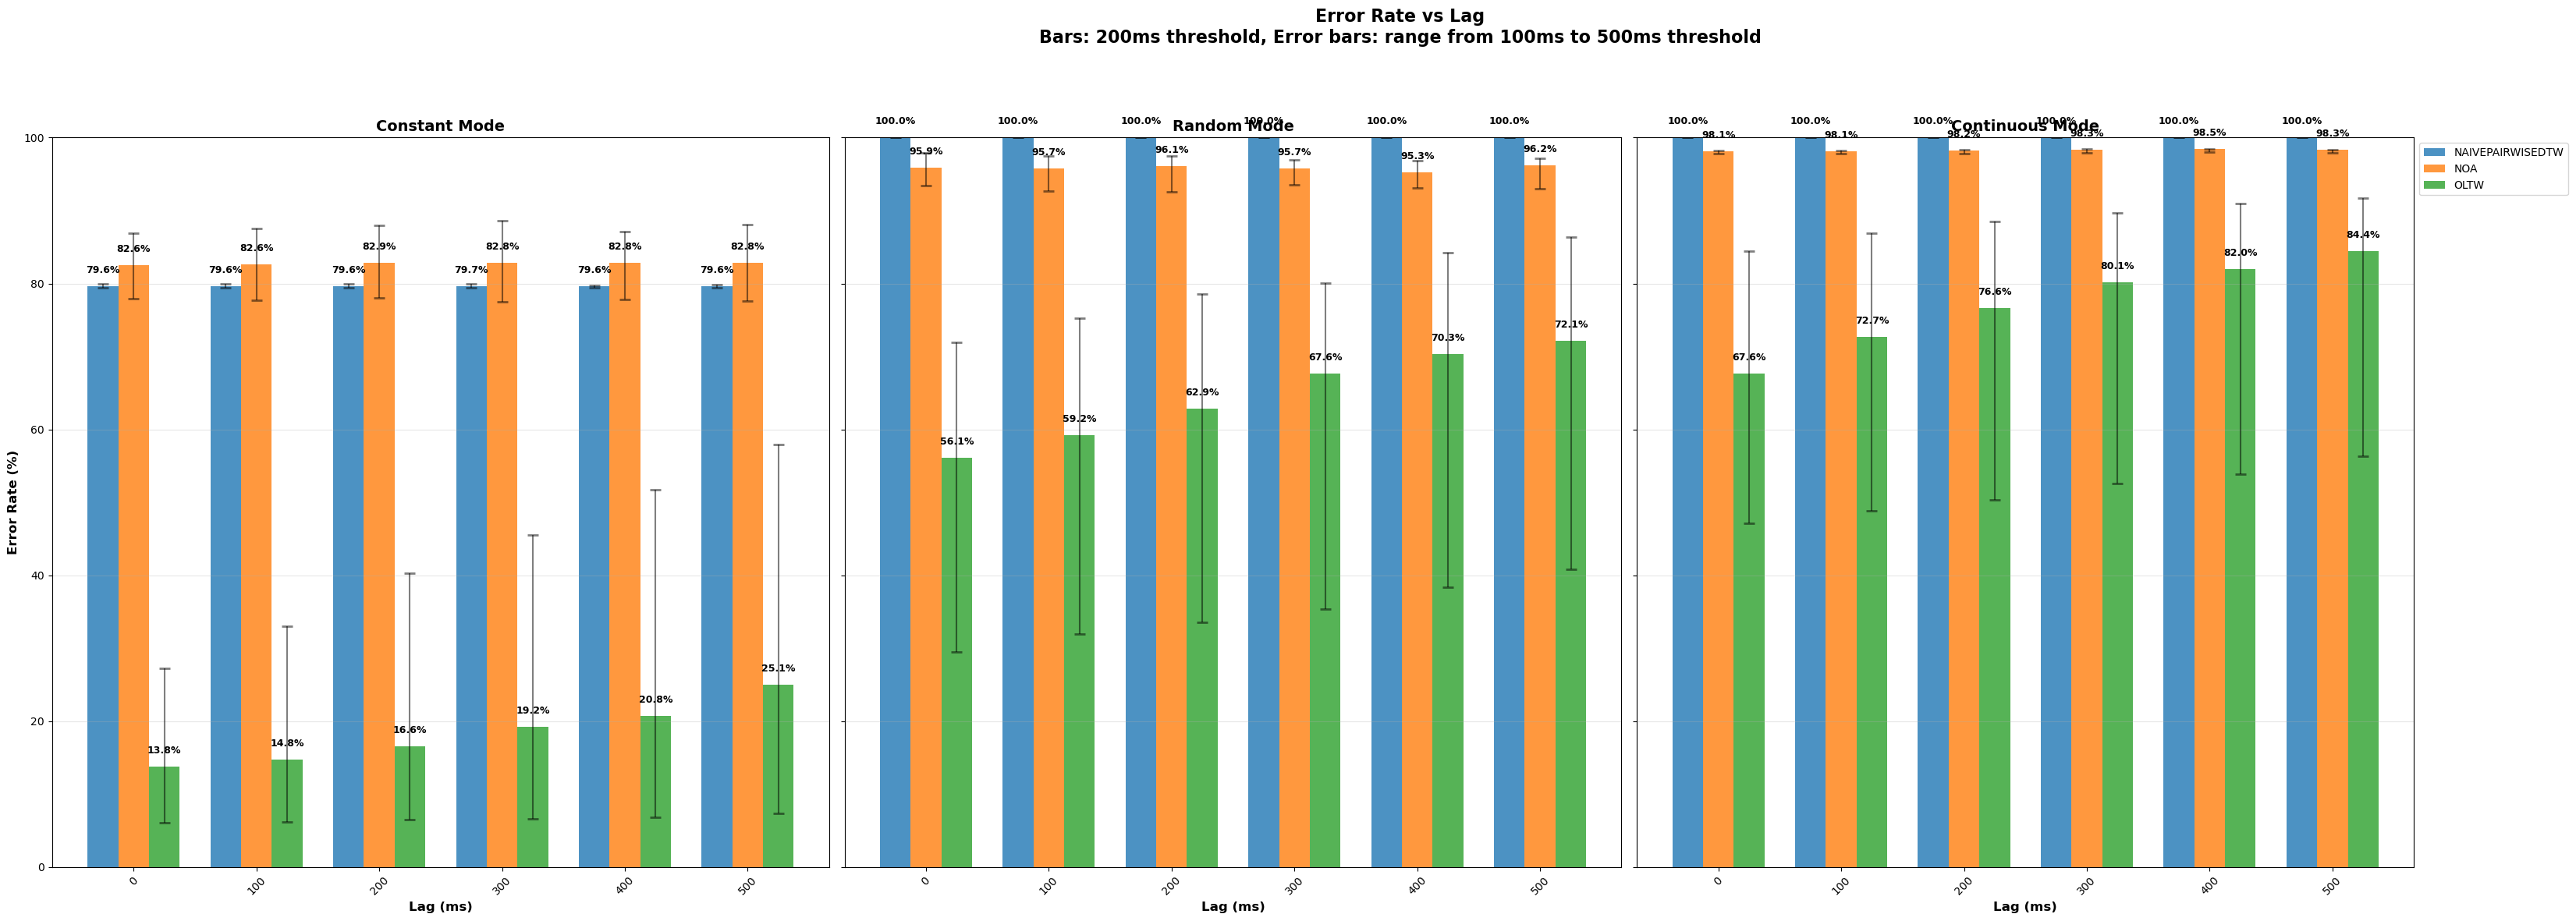

In [15]:
# Create a 1x3 grid of subplots for the three evaluation modes with a wider figure
num_modes = len(modes)
fig, axes = plt.subplots(1, num_modes, figsize=(36 * num_modes // 3, 12), sharey=True)

# Ensure axes is always an array, even if num_modes=1
if num_modes == 1:
    axes = [axes]

x = np.arange(len(lags))
width = 0.25  # Width of each bar group
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Blue, Orange, Green

for idx, eval_mode in enumerate(modes):
    ax = axes[idx]
    for i, system in enumerate(systems):
        # Retrieve error rates for this system/mode across lags/tols
        system_data = errors_dict[eval_mode][system]
        
        # Collect error rates for each lag at each threshold
        upper_error = [system_data[lag][tols[0]] * 100 for lag in lags]
        middle_error = [system_data[lag][tols[1]] * 100 for lag in lags]
        lower_error = [system_data[lag][tols[2]] * 100 for lag in lags]

        # Calculate bar positions for this system
        bar_positions = x + i * width

        # Plot the main bars (middle threshold)
        bars = ax.bar(bar_positions, middle_error, width, 
                      label=f'{system.upper()}', color=colors[i], alpha=0.8)
        
        # Prepare error bars: must all be positive for matplotlib!
        yerr_lower = [max(0, middle_error[j] - lower_error[j]) for j in range(len(middle_error))]
        yerr_upper = [max(0, upper_error[j] - middle_error[j]) for j in range(len(middle_error))]

        # Error bars centered on each bar
        ax.errorbar(
            bar_positions,
            middle_error,
            yerr=[yerr_lower, yerr_upper],
            fmt='none',
            color='black',
            capsize=5,
            capthick=2,
            linewidth=1.5,
            alpha=0.5
        )
        
        # Add value labels on the main bars
        for j, (pos, err) in enumerate(zip(bar_positions, middle_error)):
            ax.text(pos, err + 1.5, f'{err:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # Customize the subplot
    ax.set_xlabel('Lag (ms)', fontsize=12, fontweight='bold')
    if idx == 0:
        ax.set_ylabel('Error Rate (%)', fontsize=12, fontweight='bold')
    ax.set_title(f'{eval_mode.capitalize()} Mode', fontsize=14, fontweight='bold')
    ax.set_xticks(x + width)
    ax.set_xticklabels([f'{lag}' for lag in lags], rotation=45)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0, 100)
    if idx == num_modes - 1:
        ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

fig.suptitle(
    f'Error Rate vs Lag\n'
    f'Bars: {tols[1]}ms threshold, Error bars: range from {tols[0]}ms to {tols[2]}ms threshold',
    fontsize=16, fontweight='bold'
)
fig.tight_layout(rect=[0, 0, 0.92, 0.93])
plt.show()
